# 01 — Análise Exploratória de Dados (EDA)

**Projeto:** Industrial KPI Predictor  
**Objetivo:** Estimar o TARGET (KPI do processo) em resolução de **1 minuto** com **1 hora de antecedência**, usando 14 variáveis de processo.

---
### Roteiro desta análise
1. Carregamento e inspeção geral  
2. Análise temporal (resolução, periodicidade, gaps)  
3. Estatísticas descritivas  
4. Análise de valores ausentes (Missing Values)  
5. Análise do TARGET  
6. Análise de correlação  
7. Detecção visual de outliers  
8. Hipóteses e próximos passos

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})
sns.set_palette('tab10')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_RAW  = Path('..') / 'data' / 'raw' / 'dados_planta.csv'
FIG_DIR   = Path('..') / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'TARGET'
TS_COL     = 'TS'

print('Setup concluído ✓')

Setup concluído ✓


## 1. Carregamento e inspeção geral

In [2]:
df_raw = pd.read_csv(DATA_RAW, parse_dates=[TS_COL])

# Remove timezone info para facilitar plots
df_raw[TS_COL] = pd.to_datetime(df_raw[TS_COL], utc=True).dt.tz_convert(None)
df_raw = df_raw.set_index(TS_COL).sort_index()

print(f'Shape          : {df_raw.shape}')
print(f'Período        : {df_raw.index.min()}  : {df_raw.index.max()}')
print(f'Duração        : {(df_raw.index.max() - df_raw.index.min()).days} dias')
print(f'\nColunas ({len(df_raw.columns)}):\n  {list(df_raw.columns)}')

Shape          : (132478, 15)
Período        : 2025-10-01 04:00:00  : 2026-01-01 04:00:00
Duração        : 92 dias

Colunas (15):
  ['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'TARGET', 'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15']


In [3]:
df_raw.head()

,var1,var2,var3,var4,var5,var6,TARGET,var8,var9,var10,var11,var12,var13,var14,var15
TS,,,,,,,,,,,,,,,
2025-10-01 04:00:00,76.81861,285.6980,8.170019,149.5193,661.6836,97.57860,16.62272,430.2026,382.2714,76.08504,12.6,7.1,321.644226,34.54060,194.334320
2025-10-01 04:01:00,77.42704,287.4132,8.170019,149.5193,672.5122,97.43076,16.62272,433.6684,382.2714,76.08504,12.6,7.1,321.644226,36.34872,184.860200
2025-10-01 04:02:00,76.88915,284.2981,7.987461,149.5193,697.9288,97.29041,16.62272,431.0560,381.5530,76.08504,12.6,7.1,321.644226,35.49091,191.931400
2025-10-01 04:03:00,76.88915,285.3387,7.987461,149.5193,702.9833,97.29041,16.62272,429.4034,378.6995,76.08504,12.6,7.1,321.644226,36.06158,197.397827
2025-10-01 04:04:00,77.34672,286.4304,7.987461,149.5193,694.0051,97.06725,16.62272,429.4034,378.6995,76.08504,12.6,7.1,321.644226,35.87410,190.620224


In [4]:
df_raw.dtypes

var1      float64
var2      float64
var3      float64
var4      float64
var5      float64
var6      float64
TARGET    float64
var8      float64
var9      float64
var10     float64
var11     float64
var12     float64
var13     float64
var14     float64
var15     float64
dtype: object

## 2. Análise temporal

In [5]:
# ── Intervalo entre leituras ───────────────────────────────────────────────────
diffs = df_raw.index.to_series().diff().dropna()
print('Intervalo de aquisição (features):')
print(diffs.value_counts().head(10))

# ── Gaps: ausência de timestamps esperados ─────────────────────────────────────
expected_freq = pd.Timedelta('1min')
gaps = diffs[diffs > expected_freq * 2]
print(f'\nGaps detectados (> 2 min entre leituras): {len(gaps)}')
if len(gaps) > 0:
    print(gaps.sort_values(ascending=False).head(10))

Intervalo de aquisição (features):
TS
0 days 00:01:00    132474
0 days 00:02:00         3
Name: count, dtype: int64

Gaps detectados (> 2 min entre leituras): 0


In [6]:
# ── Frequência de mudança do TARGET (proxy para 30 min) ───────────────────────
target_changes = df_raw[TARGET_COL].diff().ne(0).sum()
total_rows = len(df_raw)
pct_mudancas = target_changes / total_rows * 100
print(f'Mudanças no TARGET: {target_changes:,} de {total_rows:,} linhas ({pct_mudancas:.1f}%)')
print('Confirma que o TARGET mantém o último valor registrado entre leituras (~30 min)')

Mudanças no TARGET: 3,760 de 132,478 linhas (2.8%)
Confirma que o TARGET mantém o último valor registrado entre leituras (~30 min)


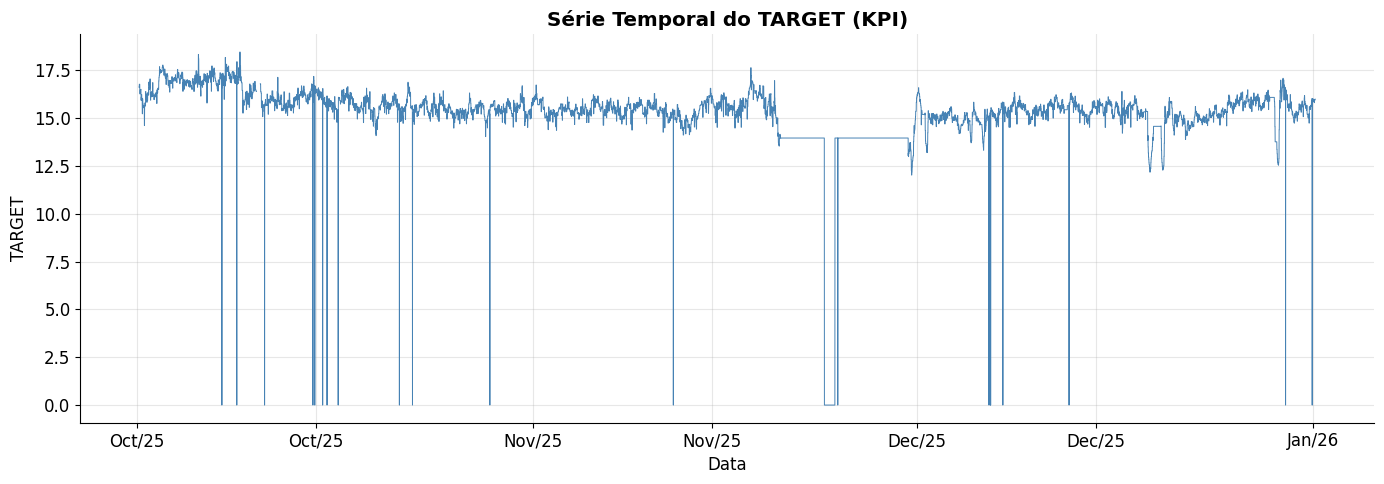

In [7]:
# ── Visualização da série do TARGET ───────────────────────────────────────────
fig, ax = plt.subplots()
ax.plot(df_raw.index, df_raw[TARGET_COL], lw=0.7, color='steelblue')
ax.set_title('Série Temporal do TARGET (KPI)', fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('TARGET')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
fig.tight_layout()
fig.savefig(FIG_DIR / 'target_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação :

#### 1. Faixa de operação normal
O TARGET oscila predominantemente entre **15 e 17.5**, indicando que o processo tem uma faixa de operação estável em regime nominal.

#### 2. Quedas bruscas para zero :
As quedas verticais até 0 visíveis ao longo dos 3 meses podem representar:
- Paradas de linha (processo interrompido)
- Falha/ausência de leitura do sensor óptico** (valor cai para zero por default).

>  Impacto no modelo:Esses zeros são outliers. Devem ser tratados mascarados como "NAN"  ou com uma feature binária Processo Ativo para o modelo distinguir os dois regimes.


Indo mais adiante das quedas bruscas: Aqui abriremos margem para talvez 2 modelos em simultaneo

In [8]:
import pandas as pd
import numpy as np

print("--- Diagnóstico Físico: Comportamento dos Sensores 60 Minutos Antes da Parada ---")

# 1. Cria uma cópia temporária para não alterar o df original da EDA
df_eda = df_raw.copy()

# 2. Simula o "olhar para o futuro" deslocando o target em -60 posições (1 hora)
df_eda['target_futuro'] = df_eda['TARGET'].shift(-60)

# Definimos os limiares (ajuste se necessário, assumindo que operação normal > 10 e parada < 1)
limiar_operacao = 10
limiar_parada = 1 

# 3. Separa os dois universos paralelos:
# Universo A: Máquina rodando normal agora, mas que VAI PARAR daqui a 60 min
condicao_pre_queda = (df_eda['TARGET'] >= limiar_operacao) & (df_eda['target_futuro'] <= limiar_parada)
df_pre_queda = df_eda[condicao_pre_queda]

# Universo B: Máquina rodando normal agora e que CONTINUARÁ normal daqui a 60 min
condicao_normal = (df_eda['TARGET'] >= limiar_operacao) & (df_eda['target_futuro'] >= limiar_operacao)
df_normal = df_eda[condicao_normal]

# 4. Seleciona dinamicamente todos os sensores (ignorando a var14 que sabemos ser defeituosa)
sensores = [c for c in df_eda.columns if c.startswith('var') and c != 'var14']

# 5. Constrói o comparativo matemático
tabela_comparativa = pd.DataFrame({
    'Media_Operacao_Normal': df_normal[sensores].mean(),
    'Media_Pre_Queda_60min': df_pre_queda[sensores].mean()
})

# 6. Calcula o quanto o sensor "gritou" (Variação Percentual)
tabela_comparativa['Variacao_Percentual (%)'] = (
    (tabela_comparativa['Media_Pre_Queda_60min'] - tabela_comparativa['Media_Operacao_Normal']) 
    / tabela_comparativa['Media_Operacao_Normal'].replace(0, np.nan) # Evita divisao por zero
) * 100

# Exibe os resultados ordenados do maior aumento para a maior queda
display(tabela_comparativa.sort_values('Variacao_Percentual (%)', ascending=False).round(2))

print(f"\nTotal de eventos mapeados como 'Pré-Queda': {len(df_pre_queda)} minutos.")
print(f"Total de minutos em operação contínua e estável: {len(df_normal)} minutos.")


--- Diagnóstico Físico: Comportamento dos Sensores 60 Minutos Antes da Parada ---


,Media_Operacao_Normal,Media_Pre_Queda_60min,Variacao_Percentual (%)
var12,7.15,7.35,2.73
var11,11.90,11.70,-1.66
var13,351.75,237.48,-32.49
var6,89.98,56.55,-37.15
var4,138.70,80.61,-41.89
var10,64.70,34.86,-46.12
var2,221.88,116.94,-47.30
var8,372.27,183.55,-50.69
var15,161.05,78.04,-51.54
var5,583.01,282.04,-51.62



Total de eventos mapeados como 'Pré-Queda': 111 minutos.
Total de minutos em operação contínua e estável: 130575 minutos.


## 3. Estatísticas descritivas

In [9]:
stats = df_raw.describe().T
stats['cv'] = (stats['std'] / stats['mean']).abs()  # coeficiente de variação
stats.style.background_gradient(cmap='YlOrRd', subset=['cv', 'std']).format(precision=3)

,count,mean,std,min,25%,50%,75%,max,cv
var1,132368.000,81.225,34.272,-7.154,78.261,88.759,98.883,288.805,0.422
var2,132370.000,219.955,98.758,-28.473,174.865,267.083,278.015,377.607,0.449
var3,132362.000,5.793,12.767,-14.965,6.279,7.132,8.125,317.514,2.204
var4,132029.000,137.384,37.341,0.000,148.955,150.234,150.958,159.602,0.272
var5,132370.000,577.600,230.424,-70.605,591.867,660.127,707.375,876.823,0.399
var6,132369.000,89.352,21.351,0.000,96.455,97.288,97.899,115.818,0.239
TARGET,132048.000,15.283,1.719,0.000,15.012,15.477,15.876,18.465,0.112
var8,132368.000,368.769,146.378,-142.364,395.359,416.650,436.381,1680.839,0.397
var9,132368.000,342.708,134.693,-3.700,346.703,395.272,415.405,531.707,0.393
var10,131940.000,64.082,29.199,-16.576,60.766,78.794,81.861,104.395,0.456


### Interpretação — Estatísticas Descritivas
`var14` é claramente problemática.
O desvio padrão de 166.162 e o CV de 88.13 estão completamente fora da realidade das outras variáveis. Os valores extremos (mínimo de -36 milhões, máximo de 21 bilhões) indicam erros de leitura do sensor. provavelmente picos pontuais que corrompem a média. Precisa de tratamento antes de qualquer coisa.

`var3` também merece atenção.
CV de 2.204 com mediana em 7.1, mas máximo de 317. A distribuição é fortemente assimétrica, o que sugere outliers que vão atrapalhar o ajuste do modelo se não forem tratados.

O TARGET é bastante estável.
CV de apenas 0.112 — a grande maioria das leituras fica entre 15 e 16. O mínimo de 0 corresponde às paradas de linha que já vimos na série temporal.

**As escalas são muito diferentes entre variáveis.**
`var11` tem média ~11, `var8` tem ~368, `var14` tem ~1885. Para algoritmos sensíveis a escala (regressão linear, SVM, redes neurais), normalização é obrigatória. Para tree-based (LightGBM, XGBoost), não é estritamente necessário, testaremos todos.


## 4. Análise de valores ausentes

        count       pct
var10     538  0.406105
var4      449  0.338924
TARGET    430  0.324582
var11     420  0.317034
var13     280  0.211356
var12     238  0.179652
var3      116  0.087562
var8      110  0.083033
var9      110  0.083033
var1      110  0.083033
var6      109  0.082278
var14     109  0.082278
var2      108  0.081523
var5      108  0.081523
var15     108  0.081523


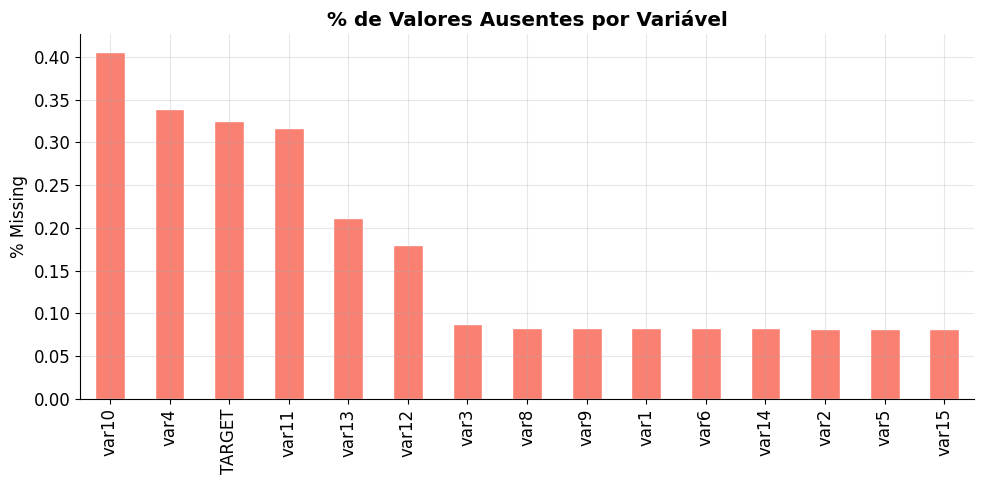

In [10]:
missing = df_raw.isnull().sum().rename('count')
missing_pct = (missing / len(df_raw) * 100).rename('pct')
missing_df = pd.concat([missing, missing_pct], axis=1).sort_values('pct', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
missing_df['pct'].plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('% de Valores Ausentes por Variável', fontweight='bold')
ax.set_ylabel('% Missing')
ax.set_xlabel('')
fig.tight_layout()
fig.savefig(FIG_DIR / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação Valores Ausentes
Os percentuais de nulos são baixos em todas as variáveis (menos de 0,5%), o que é positivo não há colapso de dados em nenhuma coluna.
Ainda assim, alguns pontos merecem atenção:
**`var10` e `var4`** têm os maiores percentuais (0.41% e 0.34%). Dado que a série tem granularidade de 1 minuto, isso representa respectivamente ~538 e ~449 minutos sem leitura ao longo de 3 meses, períodos que podem estar associados a manutenção ou falha do sensor.
**`TARGET`** também tem 430 nulos (0.32%). Esses pontos coincidem provavelmente com as quedas para zero vistas na série temporal que o sensor óptico não registrou leitura. Na etapa de pré-processamento, esses registros precisam ser tratados com cuidado: simplesmente interpolar o TARGET seria incorreto, pois o zero não é "dado faltante" é um estado real do processo (linha parada).
**`var11` e `var13`** têm 420 e 280 nulos respectivamente. Vale cruzar temporalmente com os nulos do TARGET para verificar se as ausências ocorrem nos mesmos momentos o que indicaria parada geral do processo, e não falha isolada de sensor.

- Para as features: interpolação linear para lacunas curtas (1–5 min), forward-fill para lacunas maiores.
- Para o TARGET: criar uma flag `processo_ativo` (0 quando TARGET = 0 ou nulo) e tratar esses períodos separadamente do regime normal.

## 5. Análise do TARGET

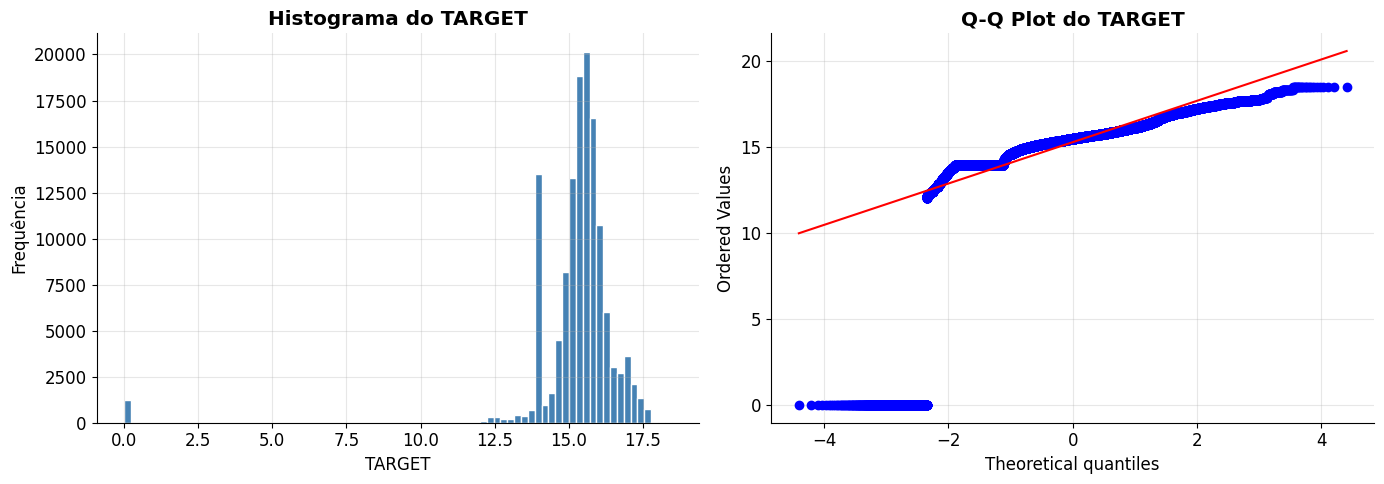

In [11]:
# ── Distribuição do TARGET ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_raw[TARGET_COL].hist(bins=80, ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Histograma do TARGET', fontweight='bold')
ax1.set_xlabel('TARGET')
ax1.set_ylabel('Frequência')

from scipy import stats as sp_stats
sp_stats.probplot(df_raw[TARGET_COL].dropna(), plot=ax2)
ax2.set_title('Q-Q Plot do TARGET', fontweight='bold')

fig.tight_layout()
fig.savefig(FIG_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação — Histograma e Q-Q Plot do TARGET
**O histograma revela dois grupos distintos de valores:**
- Um pico isolado próximo de 0, correspondente às paradas de linha que já identificamos.
- Uma distribuição concentrada entre 15 e 17.5, que representa o regime normal de operação do processo.
Isso confirma que o TARGET não segue uma distribuição unimodal — há dois estados claramente separados.

**Implicações para o modelo:**
- Algoritmos que assumem normalidade dos resíduos (como regressão linear padrão) podem ter dificuldades. Modelos baseados em árvores (Random Forest, LightGBM) são mais robustos a isso.
- A separação dos dois regimes reforça a necessidade da flag `processo_ativo` — treinar o modelo com os zeros misturados aos valores normais vai degradar a performance.
- Uma alternativa é filtrar os períodos de parada antes do treinamento e modelar apenas o regime normal.

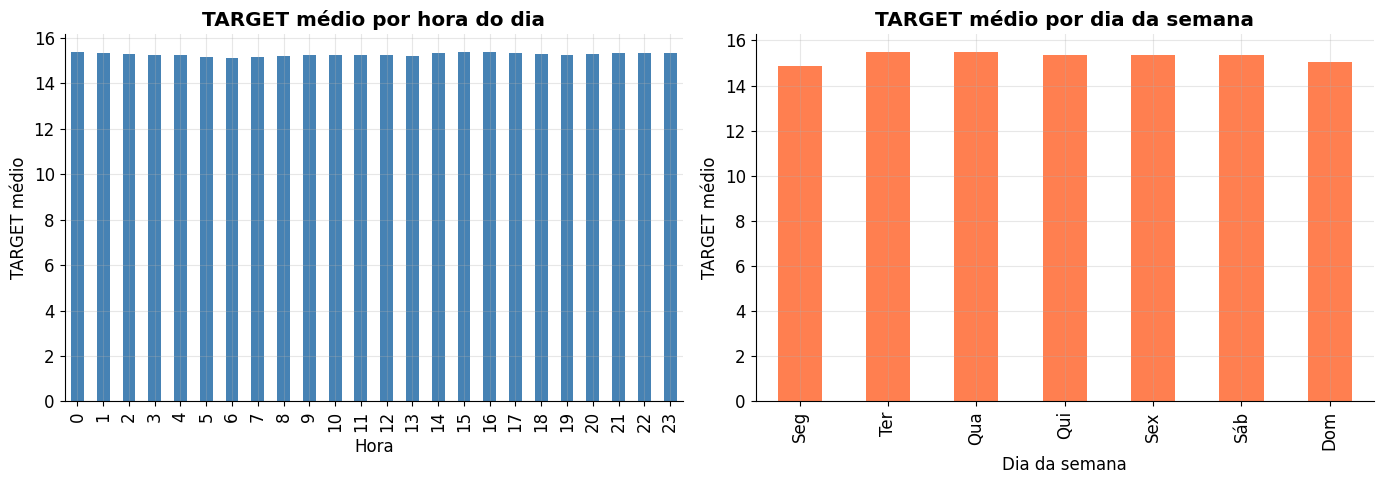

In [12]:
# ── Padrão horário e diário do TARGET ─────────────────────────────────────────
df_analysis = df_raw.copy()
df_analysis['hour']       = df_analysis.index.hour
df_analysis['dayofweek']  = df_analysis.index.dayofweek  # 0=segunda, 6=domingo

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_analysis.groupby('hour')[TARGET_COL].mean().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('TARGET médio por hora do dia', fontweight='bold')
ax1.set_xlabel('Hora')
ax1.set_ylabel('TARGET médio')

day_labels = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
df_analysis.groupby('dayofweek')[TARGET_COL].mean().rename(index=dict(enumerate(day_labels))).plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('TARGET médio por dia da semana', fontweight='bold')
ax2.set_xlabel('Dia da semana')
ax2.set_ylabel('TARGET médio')

fig.tight_layout()
fig.savefig(FIG_DIR / 'target_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusão:** A sazonalidade relevante aqui é diária, não semanal (mas ainda é pouquinho). Criar uma feature de hora do dia faz sentido; criar features de dia da semana pode não agregar muito valor. Saberemos isso ao testar.

## 6. Análise de correlação

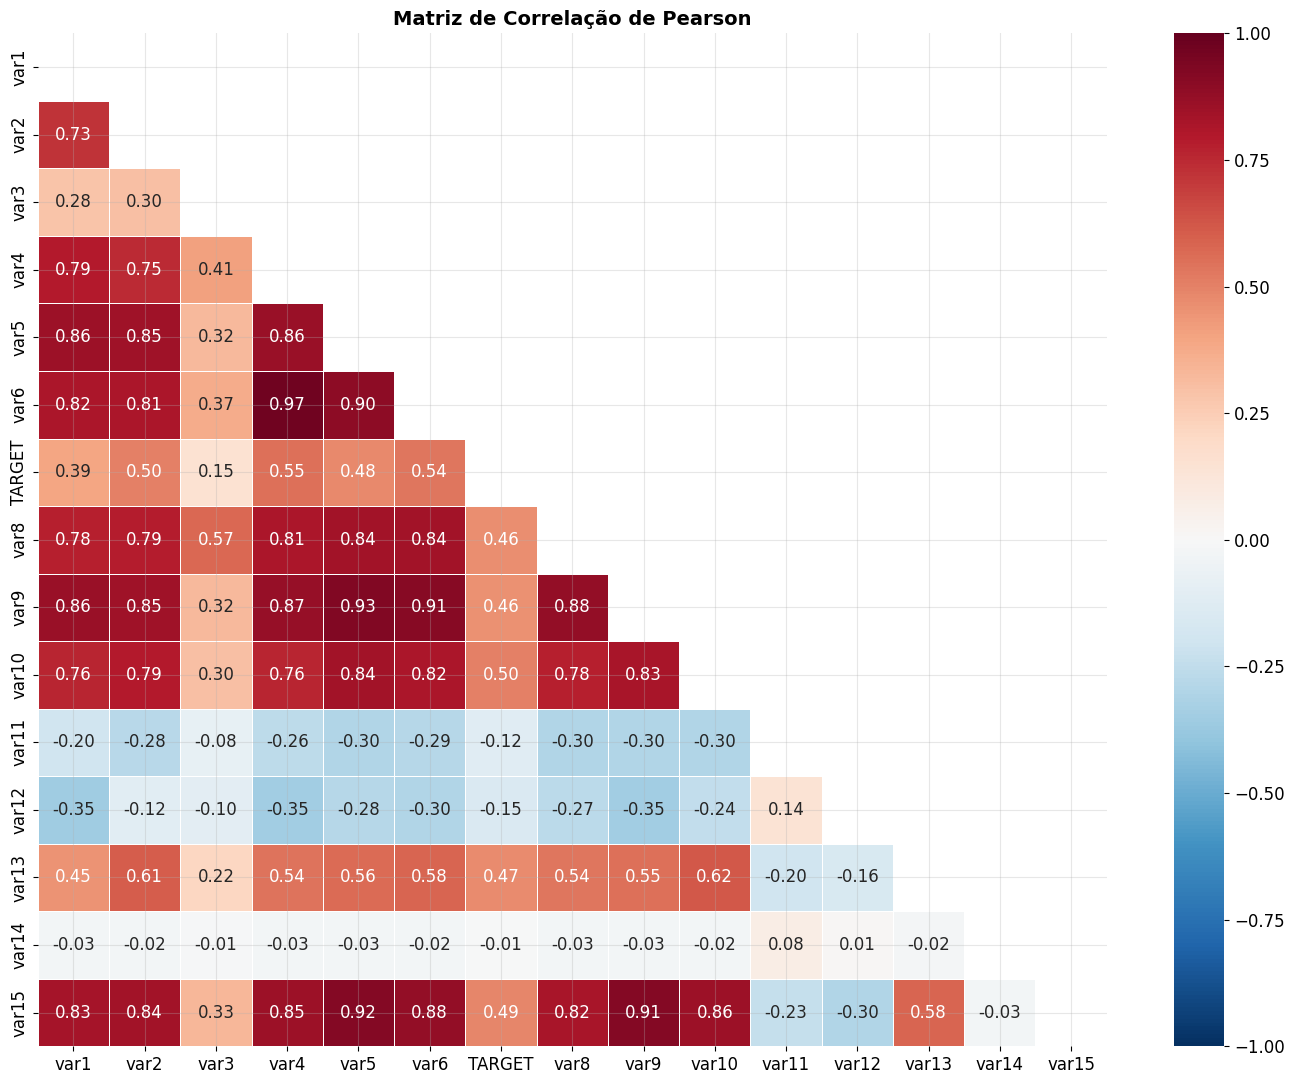

In [13]:
# [SINCRONIZACAO SOURCE]: Aplicando shift(-60) no TARGET antes da correlacao para evitar Data Leakage reativo (T vs T)
# ── Correlação de Pearson (linear) ────────────────────────────────────────────
df_corr = df_raw.copy()
df_corr[TARGET_COL] = df_corr[TARGET_COL].shift(-60)
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Correlação de Pearson', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

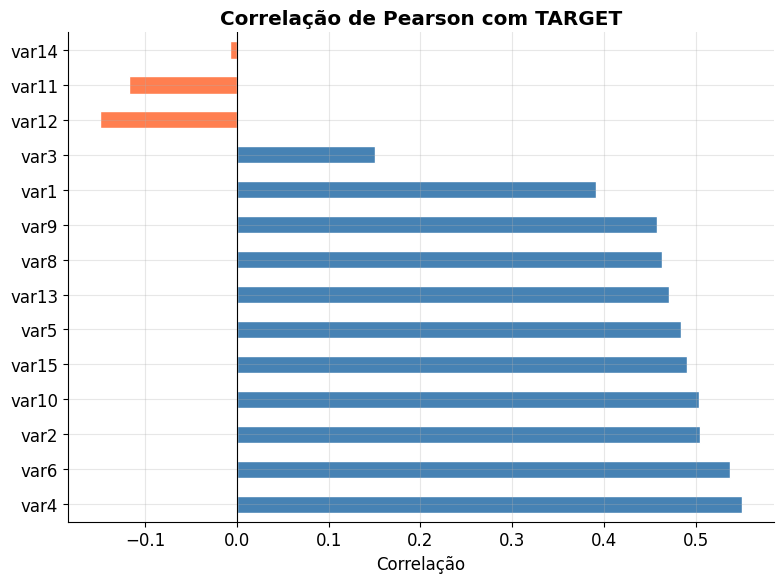


Top correlações com TARGET:
var4     0.550458
var6     0.537908
var2     0.504705
var10    0.503266
var15    0.490185
var5     0.483599
var13    0.470874
var8     0.463247
var9     0.458096
var1     0.391583
var3     0.151064
var12   -0.149173
var11   -0.117976
var14   -0.007380
Name: TARGET, dtype: float64


In [14]:
# ── Correlação com o TARGET (ranking) ─────────────────────────────────────────
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if v >= 0 else 'coral' for v in target_corr]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'Correlação de Pearson com {TARGET_COL}', fontweight='bold')
ax.set_xlabel('Correlação')
fig.tight_layout()
fig.savefig(FIG_DIR / 'target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlações com TARGET:')
print(target_corr)

### Interpretação — Heatmap de Correlação entre Features
**Grupos de alta correlação entre si (multicolinearidade):**
- `var4`, `var5`, `var6`, `var9`, `var15` formam um bloco com correlações altíssimas (0,85–0,97 entre si). Esse grupo provavelmente representa sensores medindo aspectos relacionados do mesmo processo.
- `var1`, `var2`, `var8`, `var10` formam outro grupo coeso (0,76–0,86 entre si).
**Implicações:**
- Em modelos lineares, essa multicolinearidade seria problemática. Em modelos de árvore (Random Forest, LightGBM), ela é mais tolerável, mas pode gerar redundância — vale considerar seleção ou engenharia de features.
- `var3`, `var11`, `var12` e `var14` têm comportamento distinto dos demais: baixa correlação com o grupo principal, o que pode indicar sensores de natureza diferente.
- `var11` e `var12` têm correlações negativas com quase todas as outras features, sugerindo que se comportam de forma inversa às demais variáveis operacionais.

## 8. Detecção visual de outliers

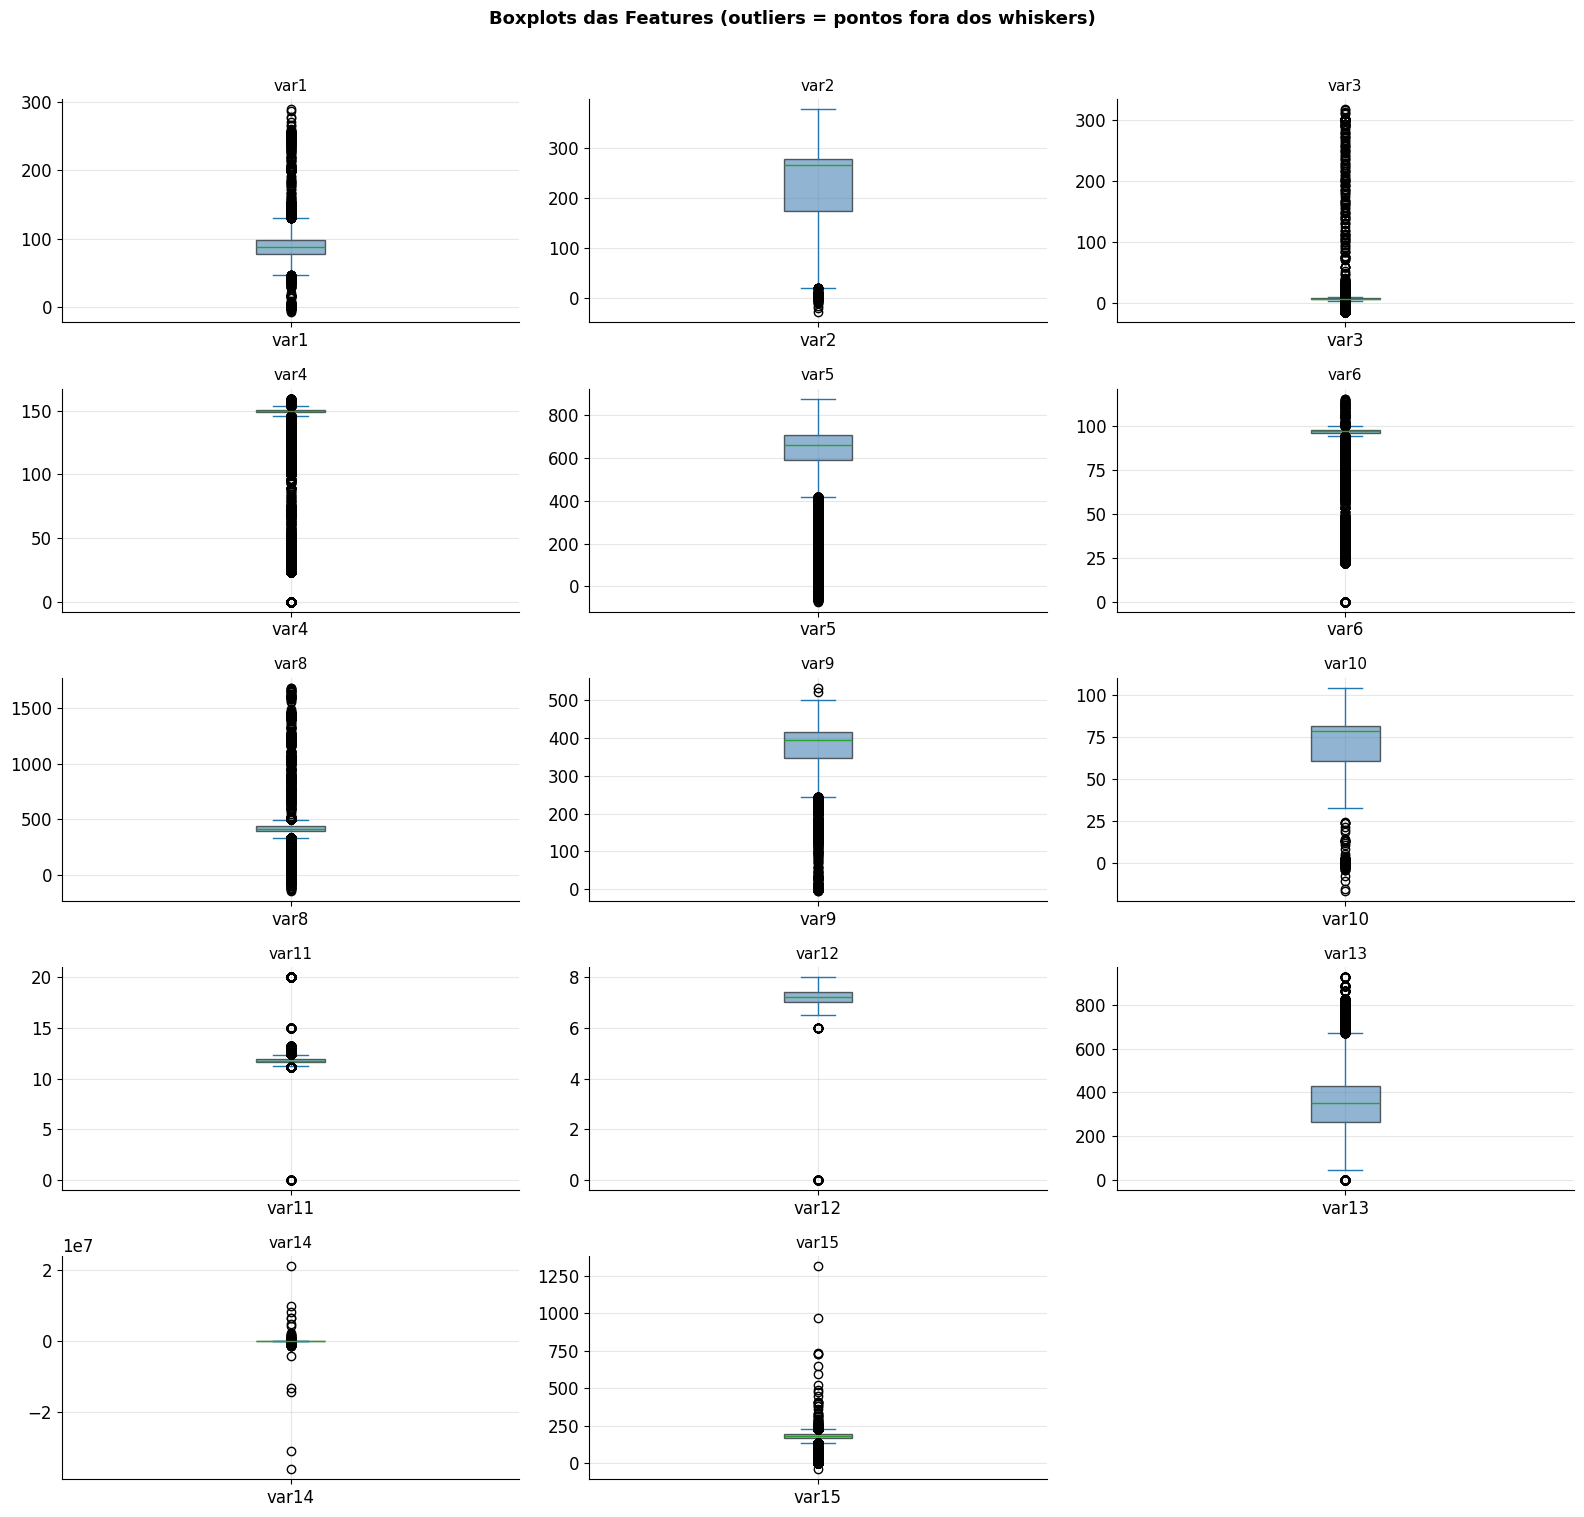

In [15]:
# ── Boxplots ──────────────────────────────────────────────────────────────────
import numpy as np
feature_cols = [col for col in df_raw.columns if col not in ['TARGET', 'TS']]
#tira o TARGET e o TS)
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

axes = axes.flatten()

for i, col in enumerate(feature_cols):
    df_raw[col].plot(kind='box', ax=axes[i], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots das Features (outliers = pontos fora dos whiskers)', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Contagem de outliers por IQR ──────────────────────────────────────────────
outlier_summary = {}
for col in df_raw.columns:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = (~df_raw[col].between(lower, upper) & df_raw[col].notna()).sum()
    pct = n_outliers / df_raw[col].notna().sum() * 100
    outlier_summary[col] = {'n_outliers': n_outliers, 'pct': round(pct, 2), 'IQR_lower': lower, 'IQR_upper': upper}

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('pct', ascending=False)
print('Outliers por variável (critério IQR × 1.5):')
outlier_df

Outliers por variável (critério IQR × 1.5):


,n_outliers,pct,IQR_lower,IQR_upper
var6,21937.0,16.57,94.288475,100.064995
var15,21607.0,16.32,135.574147,225.981360
var10,21230.0,16.09,29.123530,113.503450
var8,19910.0,15.04,333.824937,497.915237
var1,18843.0,14.24,47.326609,129.817259
var5,18633.0,14.08,418.604913,880.637212
var3,17507.0,13.23,3.510863,10.893023
var9,17153.0,12.96,243.651188,518.456688
var4,16948.0,12.84,145.950950,153.961750
var14,16939.0,12.80,23.326105,50.805665


### Interpretação — Boxplots e Análise de Outliers
Padrão geral:
A maioria das features apresenta uma cauda inferior longa com valores próximos de zero. Esse padrão é consistente com o que já identificamos: os zeros representam períodos de parada da planta, não erros de sensor.
Features com maior percentual de outliers (~15–16%):
- `var6`, `var15`, `var10`, `var8`: são exatamente as features que formam o grupo de alta correlação entre si. Os "outliers" nessas variáveis provavelmente correspondem aos momentos de parada da linha.
`var14` — caso especial:
- O boxplot revela valores em escala de 10⁷, completamente fora da ordem de grandeza das outras features.
- Mesmo assim, tem a menor correlação com o TARGET (-0,01) e ~12,8% de "outliers" pelo critério IQR.
- Essa variável precisa de atenção no pré-processamento: ou normalização robusta, ou possível exclusão se for ruído.
`var11` e `var12` — baixa variabilidade:
- Distribuições muito compactas (IQR estreito), com apenas poucos pontos fora.
- Confirma o que os dados descritivos já mostraram: essas variáveis têm baixa variabilidade e fraca correlação com o TARGET.
`var13` — poucos outliers, mas relevante:
- Apenas 1,29% de outliers pelo critério IQR, distribuição relativamente estável.
- Ainda assim, tem correlação de 0,50 com o TARGET  será uma boa feature.
Estratégia de tratamento de outliers:
- Para a maioria das features: os "outliers" para baixo refletem paradas e serão tratados pela flag `processo_ativo`.
- Para `var14`: aplicar clipping ou transformação robusta antes de modelar.
- Para `var11` e `var12`: baixa prioridade — pouca informação preditiva.

## 8. próximos passos

### Variáveis mais promissoras para o modelo
| Feature | Correlação com TARGET | Observação |
|---|---|---|
| `var4` | 0,56 | Melhor correlação linear; em grupo altamente coeso |
| `var6` | 0,55 | Idem; tem falha prolongada no final da série |
| `var2` | 0,51 | Alta correlação; menos redundante que o grupo var4/var6 |
| `var10` | 0,51 | Idem |
| `var13` | 0,50 | Baixos outliers, distribuição estável |
| `var15` | 0,50 | Grupo coeso com var4/var5/var6/var9 |
| `var1` | 0,39 | Contribuição moderada |
| `var3` | 0,15 | Baixa correlação linear — pode ter relação não linear |
**Features com baixa utilidade:** `var11`, `var12` (correlação negativa fraca), `var14` (quase zero correlação, escala anômala).
---

1. Criar flag `processo_ativo` (TARGET > threshold).
2. Aplicar shift de -60 minutos no TARGET (horizonte de previsão de 1h).
3. Tratar valores ausentes: interpolação linear (lacunas curtas) e forward-fill (lacunas longas).
4. Tratar outliers de `var14` com clipping nos percentis 1–99.
5. Gerar features de tempo: hora do dia (cíclica), dia da semana.
6. Gerar lags (t-1, t-5, t-10, t-30 minutos) e médias móveis (5, 15, 30 min) para as features mais correlacionadas.
7. Avaliar seleção ou compressão do grupo `var4`/`var5`/`var6`/`var9`/`var15`.
